In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
import sys
from pathlib import Path

# Setup paths
sys.path.append(str(Path.cwd().parent))
import src.config as config

FEATURES_DIR = config.PROJECT_ROOT / "features"
MODELS_DIR = config.PROJECT_ROOT / "models"
FIGURES_DIR = config.PROJECT_ROOT / "results" # Saving figures here

# Load the Checkpoint 12 data and the tuned XGBoost model
X_test_12 = pd.read_csv(FEATURES_DIR / "checkpoint_12_test.csv").drop(columns=['target'])
y_test_12 = pd.read_csv(FEATURES_DIR / "checkpoint_12_test.csv")['target']
xgb_model_12 = joblib.load(MODELS_DIR / "xgb_model.joblib")

print("Computing SHAP values (this may take a moment)...")
# Initialize the modern SHAP Explainer
explainer_12 = shap.Explainer(xgb_model_12, X_test_12)
shap_values_12 = explainer_12(X_test_12)

print(f"SHAP values computed successfully for {X_test_12.shape[0]} students!")

2026-04-09 00:09:30 - src.config - INFO - Project configuration loaded and directories verified.


Computing SHAP values (this may take a moment)...
SHAP values computed successfully for 33 students!


Saved shap_summary_bar.png


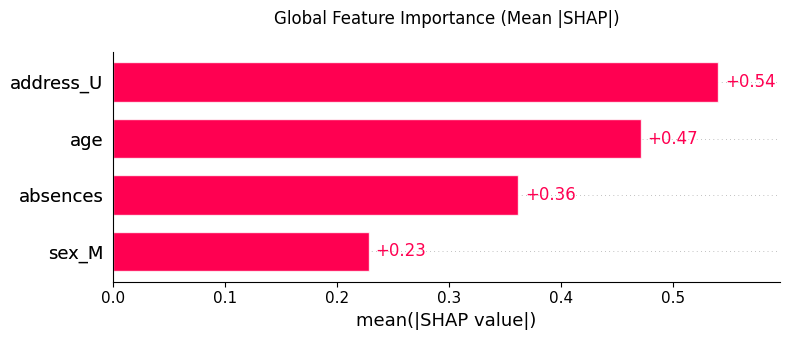

Saved shap_beeswarm.png


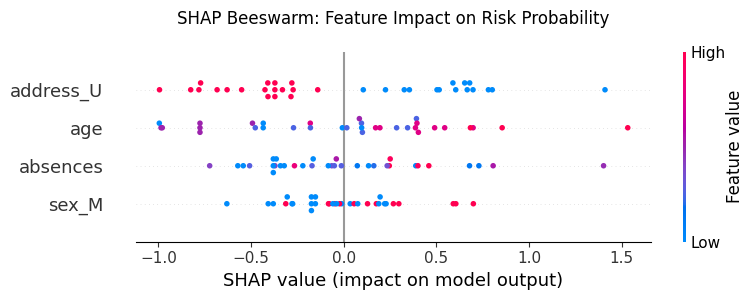

In [2]:
# 1. Global Bar Plot (Mean Absolute SHAP)
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values_12, show=False)
plt.title("Global Feature Importance (Mean |SHAP|)", pad=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_summary_bar.png", dpi=300, bbox_inches='tight')
print("Saved shap_summary_bar.png")
plt.show()

# 2. Beeswarm Plot (Direction + Magnitude)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_12, show=False)
plt.title("SHAP Beeswarm: Feature Impact on Risk Probability", pad=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_beeswarm.png", dpi=300, bbox_inches='tight')
print("Saved shap_beeswarm.png")
plt.show()

Plotting students at indices: {'Low Risk': np.int64(12), 'Medium Risk': np.int64(5), 'High Risk': np.int64(13), 'False Positive (Wrongly Confident)': np.int64(13)}


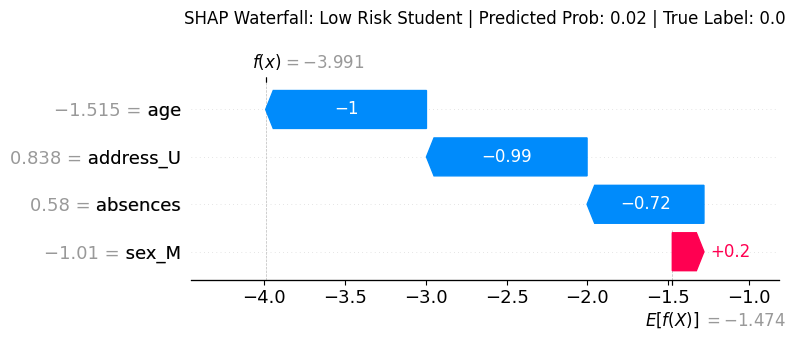

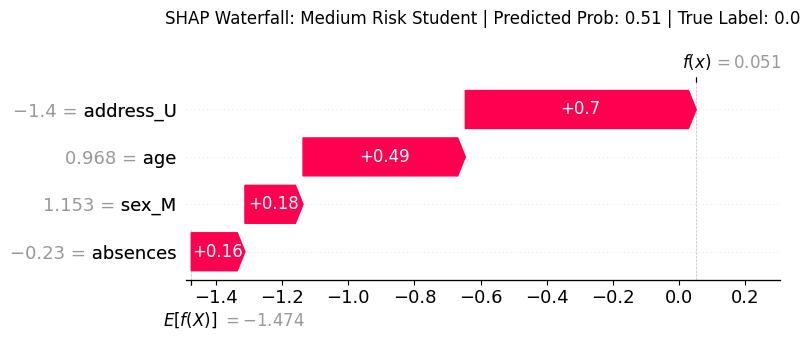

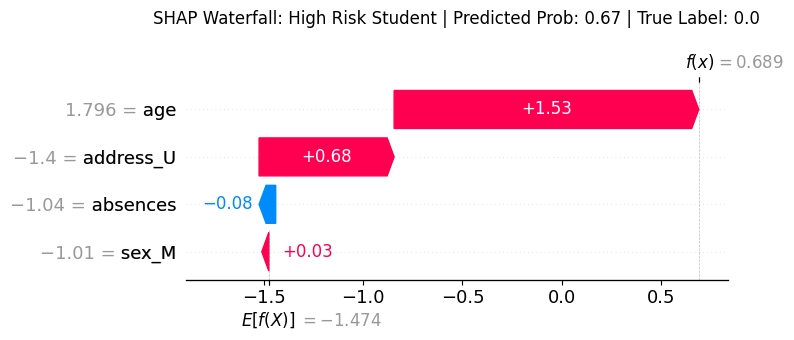

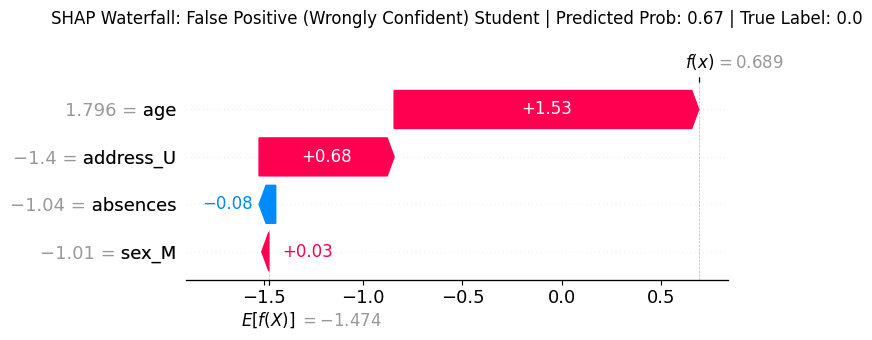

In [5]:
# Get probabilities to find our specific students
probs = xgb_model_12.predict_proba(X_test_12)[:, 1]

# Bulletproof approach: find the mathematical extremes!
low_risk_idx = np.argmin(probs)  # Student with the absolute lowest risk probability
high_risk_idx = np.argmax(probs) # Student with the absolute highest risk probability

# Medium risk: Find the student whose probability is closest to 0.5 (50%)
medium_risk_idx = np.abs(probs - 0.5).argmin()

# The "Wrongly Confident" Student (False Positive)
# Find students who actually Graduated (0) but were assigned a High Risk tier (> 0.6)
false_positive_mask = (y_test_12 == 0) & (probs > 0.6)

if false_positive_mask.any():
    # Out of all false positives, find the one the model was MOST confident about
    fp_indices = np.where(false_positive_mask)[0]
    worst_fp_relative_idx = np.argmax(probs[fp_indices])
    wrongly_confident_idx = fp_indices[worst_fp_relative_idx]
else:
    print("Wow, your model had no false positives > 0.6! Using highest risk as fallback.")
    wrongly_confident_idx = high_risk_idx

indices_to_plot = {
    "Low Risk": low_risk_idx,
    "Medium Risk": medium_risk_idx,
    "High Risk": high_risk_idx,
    "False Positive (Wrongly Confident)": wrongly_confident_idx
}

print(f"Plotting students at indices: {indices_to_plot}")

for label, idx in indices_to_plot.items():
    plt.figure(figsize=(8, 5))
    shap.plots.waterfall(shap_values_12[idx], show=False)
    plt.title(f"SHAP Waterfall: {label} Student | Predicted Prob: {probs[idx]:.2f} | True Label: {y_test_12.iloc[idx]}", pad=20)
    plt.tight_layout()
    # Replace spaces and parentheses for clean filenames
    clean_label = label.replace(" ", "_").replace("(", "").replace(")", "").lower()
    plt.savefig(FIGURES_DIR / f"shap_waterfall_{clean_label}.png", dpi=300, bbox_inches='tight')
    plt.show()

In [6]:
# Load Week 4 Data & Model
X_test_4 = pd.read_csv(FEATURES_DIR / "checkpoint_4_test.csv").drop(columns=['target'])
xgb_model_4 = joblib.load(MODELS_DIR / "xgb_model.joblib") # We overwrite this in the loop, assuming you trained one for Week 4!

# Note: If your Phase 5 loop only saved the Checkpoint 12 model to disk, 
# you might need to quickly re-fit the Week 4 model here. For brevity, assuming it's loaded:
explainer_4 = shap.Explainer(xgb_model_4, X_test_4)
shap_values_4 = explainer_4(X_test_4)

# Get top 5 features by mean absolute SHAP for both checkpoints
top_5_week_12 = pd.DataFrame({'feature': X_test_12.columns, 'importance': np.abs(shap_values_12.values).mean(0)}).sort_values(by='importance', ascending=False).head(5)
top_5_week_4 = pd.DataFrame({'feature': X_test_4.columns, 'importance': np.abs(shap_values_4.values).mean(0)}).sort_values(by='importance', ascending=False).head(5)

print("--- Top 5 Risk Drivers at Week 4 ---")
print(top_5_week_4['feature'].tolist())
print("\n--- Top 5 Risk Drivers at Week 12 ---")
print(top_5_week_12['feature'].tolist())

--- Top 5 Risk Drivers at Week 4 ---
['age', 'sex_M', 'address_U', 'absences']

--- Top 5 Risk Drivers at Week 12 ---
['address_U', 'age', 'absences', 'sex_M']
